# 04 — Price the derivatives

Calculate base INR values for swaps, forwards, options and credit and commodity derivatives.

A derivative derives value from another market variable. Linear products mainly create delta; options also create vega and curvature.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

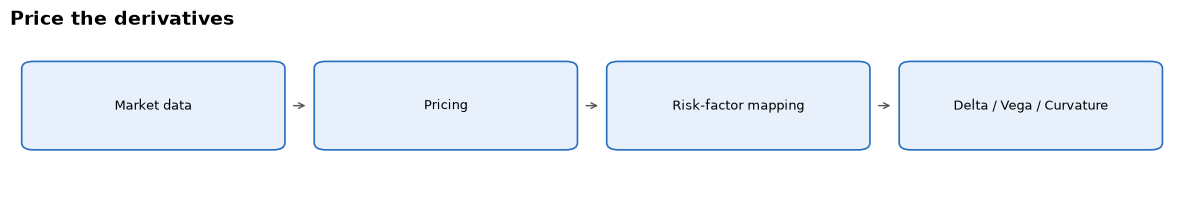

In [2]:
draw_flow(['Market data', 'Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature'],'Price the derivatives',wrap_after=4)

Transparent pricing functions combine trade terms, market inputs and long/short direction, then translate foreign values into INR.

$$V=\text{pricing model}(\text{trade terms},\text{market inputs})\times\text{direction}$$

In [3]:
values=pd.read_csv(RUN/'02_valuations.csv')
view=values[values.product_form=='derivative'].copy()
view['calculated_inr']=view.market_value_local*view.fx_to_inr
columns=['trade_id','desk','instrument_type','currency','market_value_local','fx_to_inr','market_value_inr']
display(crore_table(view[columns],['market_value_inr']))
example=view[view.currency!='INR'].iloc[0]
print(f"Worked trade {example.trade_id}: {example.market_value_local:,.2f} {example.currency} x {example.fx_to_inr:,.4f} = INR {example.market_value_inr:,.2f}")

,trade_id,desk,instrument_type,currency,market_value_local,fx_to_inr,Market Value (INR crore)
5,R06,Rates,IRS,INR,"-715,338.0864",1.0000,-0.0715
6,R07,Rates,IRS,USD,0.0000,86.2000,0.0000
7,R08,Rates,FRA,INR,"-48,473.0974",1.0000,-0.0048
8,R09,Rates,SWAPTION,INR,"4,181,352.3885",1.0000,0.4181
9,R10,Rates,SWAPTION,USD,"116,325.9991",86.2000,1.0027
11,R12,Rates,XCCY_BASIS_SWAP,USD,"3,830.0614",86.2000,0.0330
16,C05,Credit,CDS,INR,"-203,117.0623",1.0000,-0.0203
17,C06,Credit,CDS,USD,"-6,584.5407",86.2000,-0.0568
18,C07,Credit,CREDIT_OPTION,USD,"9,626.3672",86.2000,0.0830
19,C08,Credit,CALLABLE_BOND,EUR,"870,019.7825",93.4000,8.1260


Worked trade R07: 0.00 USD x 86.2000 = INR 0.00


The visual below uses the calculated rows shown above.

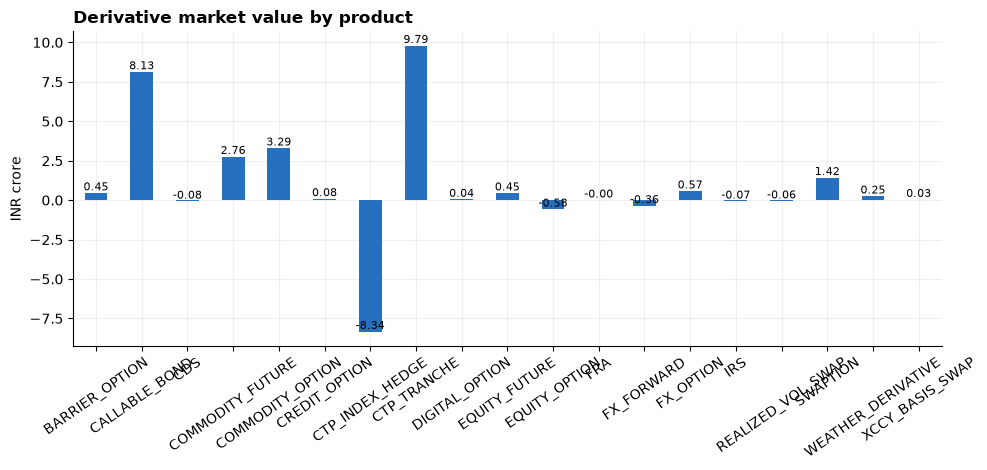

In [4]:
bar_crore(view.groupby('instrument_type')['market_value_inr'].sum(),'Derivative market value by product')

These values become the base values used in every sensitivity calculation.